# PreventaB — Complete ML Pipeline Notebook
# Explainable AI for Computer System Failure Prediction & Prevention

**Student:** Bibash Shrestha | **ID:** 77466887 | **Course:** BSc (Hons) Computing  
**Module:** Production Project (CRN 14806) | **Institution:** The British College, Kathmandu

---

### Notebook Outline
1. **Environment Setup & Package Installation + Imports**
2. **Dataset Download (KaggleHub) + Auto-Select Best CSV**
3. **Data Loading & Initial Exploration (Cloud + Windows Logs)**
4. **Column Mapping (Auto-Detection + Manual Override)**
5. **Data Cleaning & Normalization (Timestamps, 0–100 scaling, Binary Label)**
6. **Feature Engineering — Windows Event Log Counts (Hourly Severity Aggregation)**
7. **Merge Cloud Telemetry with Log-Count Features (Hour/Host Merge)**
8. **Data Quality Checks — Missing Values & Outlier Treatment (Median Fill + Winsorization)**
9. **Exploratory Data Analysis (EDA) — Matplotlib/Seaborn + Plotly Interactive**
10. **Baseline Heuristic Model (Rule-Based Risk Score + ROC Curve)**
11. **Time-Indexed Train/Test Split (Chronological 80/20)**
12. **Model Training — Baseline Models (LogReg, RandomForest, HistGradientBoosting) + ROC/PR**
13. **Hyperparameter Tuning (RandomizedSearchCV + TimeSeriesSplit fallback)**
14. **Model Evaluation — Tuned Models (Metrics Table, ROC/PR, Confusion Matrices)**
15. **Threshold Analysis & Operational Metrics (Precision/Recall/F1, FPR, FNR + App Thresholds)**
16. **Explainable AI — SHAP (Global Feature Importance + Local Explanations)**
17. **Explainable AI — LIME (Local Explanations for Selected Samples)**
18. **Recommendations & Action Mapping (SHAP-driven Admin Actions + Ranking Plot)**
19. **Export ML Artifacts for Django Integration (Model/Features/Metadata/Action Map + Kaggle Insights JSON)**
20. **Final Summary & Integration Guide (Django Usage + Risk Labels)**




---
## 1) Environment Setup & Package Installation

Install all required libraries. Run this cell once.


In [1]:
# ============================================================
# Install required packages (run once)
# ============================================================
# Uncomment and run if packages are not installed:
# !pip install -U kagglehub pandas numpy scikit-learn matplotlib seaborn plotly shap lime joblib

# Verify installations
!pip list | findstr /i "pandas numpy scikit-learn matplotlib seaborn plotly shap lime joblib"


datashape                     0.5.4
joblib                        1.1.0
lime                          0.2.0.1
matplotlib                    3.5.2
matplotlib-inline             0.1.6
numpy                         1.21.5
numpydoc                      1.4.0
pandas                        1.4.4
plotly                        5.9.0
scikit-learn                  1.0.2
scikit-learn-intelex          2021.20221004.171935
seaborn                       0.11.2
shap                          0.49.1


In [2]:
# ============================================================
# 1. Core Imports
# ============================================================
import os, sys, json, glob, gc, warnings, datetime
from dataclasses import dataclass
from typing import Optional

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Machine Learning (Scikit-Learn)
from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV,
    TimeSeriesSplit, StratifiedKFold
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report,
    accuracy_score, f1_score, precision_score, recall_score
)
import joblib

# Explainable AI
import shap
import lime
import lime.lime_tabular

# Optional: TensorFlow (only if available, for deep learning experiment)
try:
    import tensorflow as tf
    TF_AVAILABLE = True
    print(f"TensorFlow {tf.__version__} available")
except ImportError:
    TF_AVAILABLE = False
    print("TensorFlow not installed — skipping deep learning (optional)")

# Settings
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 5)

# RAM management helper
def free_mem():
    gc.collect()

print("All imports successful!")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")
print(f"Seaborn: {sns.__version__}")
print(f"Scikit-learn: {__import__('sklearn').__version__}")


TensorFlow not installed — skipping deep learning (optional)
All imports successful!
NumPy: 1.21.5
Pandas: 1.4.4
Matplotlib: 3.5.2
Seaborn: 0.11.2
Scikit-learn: 1.0.2


---
## 2) Download Kaggle Datasets with KaggleHub

We use two publicly available datasets:
- **Cloud Anomaly Data** (CPU, memory, network/power metrics + anomaly labels)
- **Windows Event Log** (system event logs with severity levels)

KaggleHub downloads datasets to a local cache and returns the directory path.


In [3]:
# ============================================================
# 2. Download Kaggle Datasets
# ============================================================
import kagglehub

CLOUD_DATASET_HANDLE = "sandhyapeesara/cloud-anomaly-data"
WINDOWS_LOGS_HANDLE  = "mehulkatara/windows-event-log"

print("Downloading Cloud Anomaly dataset...")
cloud_dir = kagglehub.dataset_download(CLOUD_DATASET_HANDLE)
print("  -> Saved to:", cloud_dir)

print("\nDownloading Windows Event Log dataset...")
logs_dir = kagglehub.dataset_download(WINDOWS_LOGS_HANDLE)
print("  -> Saved to:", logs_dir)

# List CSV files
cloud_files = glob.glob(os.path.join(cloud_dir, "**", "*.csv"), recursive=True)
log_files   = glob.glob(os.path.join(logs_dir,  "**", "*.csv"), recursive=True)

print(f"\nCloud CSVs found: {len(cloud_files)}")
for f in cloud_files[:10]:
    print(f"  - {os.path.relpath(f, cloud_dir)}")

print(f"\nWindows Log CSVs found: {len(log_files)}")
for f in log_files[:10]:
    print(f"  - {os.path.relpath(f, logs_dir)}")


  -> Saved to: C:\Users\Bibash Shrestha\.cache\kagglehub\datasets\sandhyapeesara\cloud-anomaly-data\versions\1

  -> Saved to: C:\Users\Bibash Shrestha\.cache\kagglehub\datasets\mehulkatara\windows-event-log\versions\15

Cloud CSVs found: 1
  - Cloud_Anomaly_Dataset.csv

Windows Log CSVs found: 1
  - eventlog.csv


### Auto-Select Best CSV Files

Score each CSV based on column relevance to select the most appropriate files automatically.


In [4]:
# ============================================================
# Auto-pick helper: scores CSVs by column relevance
# ============================================================
def read_csv_head(path, nrows=2000):
    return pd.read_csv(path, nrows=nrows)

def score_cloud_csv(df: pd.DataFrame) -> int:
    cols = [c.lower() for c in df.columns]
    score = 0
    if any("time" in c or "date" in c for c in cols): score += 2
    if any("cpu" in c for c in cols): score += 3
    if any(("mem" in c) or ("ram" in c) for c in cols): score += 3
    if any("disk" in c for c in cols): score += 3
    if any(("label" in c) or ("anomaly" in c) or ("fault" in c) or ("target" in c) for c in cols): score += 3
    return score

def score_logs_csv(df: pd.DataFrame) -> int:
    cols = [c.lower() for c in df.columns]
    score = 0
    if any("time" in c or "date" in c for c in cols): score += 3
    if any(("level" in c) or ("severity" in c) or ("eventlevel" in c) for c in cols): score += 3
    if any(("computer" in c) or ("machine" in c) or ("host" in c) for c in cols): score += 1
    return score

def pick_best_csv(files, scorer, label):
    best, best_score = None, -1
    for f in files:
        try:
            dfh = read_csv_head(f, nrows=2000)
            s = scorer(dfh)
            if s > best_score:
                best_score = s
                best = f
        except Exception:
            continue
    if best is None:
        raise FileNotFoundError(f"No readable CSV found for {label}.")
    print(f"Selected {label} CSV: {os.path.basename(best)} (score={best_score})")
    return best

cloud_csv = pick_best_csv(cloud_files, score_cloud_csv, "CLOUD")
logs_csv  = pick_best_csv(log_files,  score_logs_csv,  "WINDOWS_LOGS")


Selected CLOUD CSV: Cloud_Anomaly_Dataset.csv (score=11)
Selected WINDOWS_LOGS CSV: eventlog.csv (score=4)


---
## 3) Data Loading & Initial Exploration

Load both datasets and inspect their structure, shape, data types, and first rows.


In [5]:
# ============================================================
# 3. Load Datasets
# ============================================================
df_cloud = pd.read_csv(cloud_csv)
df_logs  = pd.read_csv(logs_csv)

print("=" * 60)
print("CLOUD TELEMETRY DATASET")
print("=" * 60)
print(f"Shape: {df_cloud.shape[0]} rows x {df_cloud.shape[1]} columns")
print(f"\nColumns: {list(df_cloud.columns)}")
print(f"\nData types:\n{df_cloud.dtypes}")
print(f"\nMissing values:\n{df_cloud.isnull().sum()}")
print(f"\nFirst 5 rows:")
display(df_cloud.head())

print("\n" + "=" * 60)
print("WINDOWS EVENT LOG DATASET")
print("=" * 60)
print(f"Shape: {df_logs.shape[0]} rows x {df_logs.shape[1]} columns")
print(f"\nColumns: {list(df_logs.columns)}")
print(f"\nData types:\n{df_logs.dtypes}")
print(f"\nMissing values:\n{df_logs.isnull().sum()}")
print(f"\nFirst 5 rows:")
display(df_logs.head())

print("\n" + "=" * 60)
print("STATISTICAL SUMMARY — Cloud Telemetry")
print("=" * 60)
display(df_cloud.describe())


CLOUD TELEMETRY DATASET
Shape: 277570 rows x 13 columns

Columns: ['vm_id', 'timestamp', 'cpu_usage', 'memory_usage', 'network_traffic', 'power_consumption', 'num_executed_instructions', 'execution_time', 'energy_efficiency', 'task_type', 'task_priority', 'task_status', 'Anomaly status']

Data types:
vm_id                         object
timestamp                     object
cpu_usage                    float64
memory_usage                 float64
network_traffic              float64
power_consumption            float64
num_executed_instructions    float64
execution_time               float64
energy_efficiency            float64
task_type                     object
task_priority                 object
task_status                   object
Anomaly status                 int64
dtype: object

Missing values:
vm_id                        27975
timestamp                        0
cpu_usage                    27440
memory_usage                 27795
network_traffic              27845
power_consu

,vm_id,timestamp,cpu_usage,memory_usage,network_traffic,power_consumption,num_executed_instructions,execution_time,energy_efficiency,task_type,task_priority,task_status,Anomaly status
0,c5215826-6237-4a33-9312-72c1df909881,25-01-2023 09:10,54.881350,78.950861,164.775973,287.808986,7527.0,69.345575,0.553589,network,medium,waiting,0
1,29690bc6-1f34-403b-b509-a1ecb1834fb8,26-01-2023 04:46,71.518937,29.901883,NaN,362.273569,5348.0,41.396040,0.349856,io,high,completed,0
2,2e55abc3-5bad-46cb-b445-a577f5e9bf2a,13-01-2023 23:39,NaN,92.709195,203.674847,231.467903,5483.0,24.602549,0.796277,io,medium,completed,0
3,ea8455b0-251c-4470-b7ea-8d40476e3434,14-01-2023 19:59,79.172504,2.972252,926.374030,173.559325,8644.0,55.702673,0.779499,compute,medium,completed,0
4,fd28310b-be6f-4320-a664-de02274993d9,18-01-2023 11:22,87.001215,46.620176,437.188115,77.054702,9427.0,NaN,0.207164,NaN,low,waiting,0



WINDOWS EVENT LOG DATASET
Shape: 158184 rows x 13 columns

Columns: ['Unnamed: 0', 'MachineName', 'Category', 'EntryType', 'Message', 'Source', 'TimeGenerated', 'country', 'regionName', 'city', 'zip', 'timezone', 'isp']

Data types:
Unnamed: 0        int64
MachineName      object
Category         object
EntryType        object
Message          object
Source           object
TimeGenerated    object
country          object
regionName       object
city             object
zip               int64
timezone         object
isp              object
dtype: object

Missing values:
Unnamed: 0       0
MachineName      0
Category         0
EntryType        0
Message          0
Source           0
TimeGenerated    0
country          0
regionName       0
city             0
zip              0
timezone         0
isp              0
dtype: int64

First 5 rows:


,Unnamed: 0,MachineName,Category,EntryType,Message,Source,TimeGenerated,country,regionName,city,zip,timezone,isp
0,1,LAPTOP-1MKMTVPM,(0),Information,Successfully scheduled Software Protection ser...,Software Protection Platform Service,2020-11-14 08:41:59,India,Gujarat,Ahmedabad,380007,Asia/Kolkata,GTPL A. J. Enterprise
1,2,LAPTOP-1MKMTVPM,Logging/Recovery,Error,"svchost (13360,R,98) TILEREPOSITORYS-1-5-18: E...",ESENT,2020-11-14 08:25:14,India,Gujarat,Ahmedabad,380007,Asia/Kolkata,GTPL A. J. Enterprise
2,3,LAPTOP-1MKMTVPM,Logging/Recovery,Error,"svchost (15040,R,98) TILEREPOSITORYS-1-5-18: E...",ESENT,2020-11-14 08:35:10,India,Gujarat,Ahmedabad,380007,Asia/Kolkata,GTPL A. J. Enterprise
3,4,LAPTOP-1MKMTVPM,(0),Information,Successfully scheduled Software Protection ser...,Software Protection Platform Service,2020-11-14 08:45:38,India,Gujarat,Ahmedabad,380007,Asia/Kolkata,GTPL A. J. Enterprise
4,5,LAPTOP-1MKMTVPM,(0),Information,Successfully created restore point (Process = ...,System Restore,2020-11-14 08:22:34,India,Gujarat,Ahmedabad,380007,Asia/Kolkata,GTPL A. J. Enterprise



STATISTICAL SUMMARY — Cloud Telemetry


,cpu_usage,memory_usage,network_traffic,power_consumption,num_executed_instructions,execution_time,energy_efficiency,Anomaly status
count,250130.000000,249775.000000,249725.000000,250018.000000,249637.000000,249960.000000,249616.000000,277570.000000
mean,50.013258,49.967249,500.554083,249.987238,5002.490284,50.011964,0.500369,0.059999
std,28.895806,28.879090,288.787794,144.662676,2882.806422,28.837634,0.288547,0.237486
min,0.000071,0.000016,0.002542,0.000802,0.000000,0.000172,0.000004,0.000000
25%,24.880023,24.965105,250.298114,124.199907,2506.000000,25.098016,0.250375,0.000000
50%,50.023806,49.912051,500.736963,250.397212,5000.000000,50.005593,0.500834,0.000000
75%,75.097896,74.960052,750.720026,375.485305,7499.000000,75.043715,0.750112,0.000000
max,99.999171,99.999907,999.998686,499.998819,9999.000000,99.998831,0.999994,1.000000


---
## 4) Column Mapping (Auto-Detection + Manual Override)

Robust auto-detection of relevant columns with fallback manual overrides.


In [6]:
# ============================================================
# 4. Column Mapping — Auto-Detection
# ============================================================
def find_first_col(df, keywords):
    cols = df.columns.tolist()
    low = [c.lower() for c in cols]
    for kw in keywords:
        kw = kw.lower()
        for i, c in enumerate(low):
            if kw in c:
                return cols[i]
    return None

@dataclass
class CloudMap:
    time_col: str
    cpu_col: str
    mem_col: str
    disk_col: str
    label_col: str
    host_col: Optional[str] = None

@dataclass
class LogMap:
    time_col: str
    level_col: str
    host_col: Optional[str] = None

# ---- Auto-detect cloud columns ----
cloud_time = find_first_col(df_cloud, ["timestamp", "time", "date"])
cloud_cpu  = find_first_col(df_cloud, ["cpu_usage", "cpu"])
cloud_mem  = find_first_col(df_cloud, ["memory_usage", "memory", "mem", "ram"])

# Disk proxy: dataset may not have direct disk column
cloud_disk = (
    find_first_col(df_cloud, ["disk", "storage", "io"])
    or find_first_col(df_cloud, ["power_consumption", "power"])
    or find_first_col(df_cloud, ["network_traffic", "network"])
)

cloud_lbl  = find_first_col(df_cloud, ["anomaly status", "anomaly", "label", "target", "fault", "failure"])
cloud_host = find_first_col(df_cloud, ["vm_id", "machine", "host", "computer", "instance", "vm", "node", "id"])

cloud_map = CloudMap(
    time_col=cloud_time, cpu_col=cloud_cpu, mem_col=cloud_mem,
    disk_col=cloud_disk, label_col=cloud_lbl, host_col=cloud_host
)
print("Cloud column mapping:", cloud_map)

# ---- Auto-detect log columns ----
log_time = find_first_col(df_logs, ["timegenerated", "timecreated", "timestamp", "time", "date"])
log_lvl  = find_first_col(df_logs, ["entrytype", "level", "severity", "eventlevel"])
log_host = find_first_col(df_logs, ["machinename", "computer", "machine", "host", "node", "id"])

log_map = LogMap(time_col=log_time, level_col=log_lvl, host_col=log_host)
print("Log column mapping:", log_map)

# ---- Manual override (uncomment ONLY if auto-detection fails) ----
# cloud_map.time_col = "timestamp"
# cloud_map.cpu_col  = "cpu_usage"
# cloud_map.mem_col  = "memory_usage"
# cloud_map.disk_col = "power_consumption"
# cloud_map.label_col= "Anomaly status"
# cloud_map.host_col = "vm_id"
# log_map.time_col   = "TimeGenerated"
# log_map.level_col  = "EntryType"
# log_map.host_col   = "MachineName"

# Validate
required_cloud = [cloud_map.time_col, cloud_map.cpu_col, cloud_map.mem_col,
                  cloud_map.disk_col, cloud_map.label_col]
assert all(x is not None for x in required_cloud), \
    f"Cloud mapping failed. Check df_cloud.columns. Detected: {cloud_map}"

required_logs = [log_map.time_col, log_map.level_col]
assert all(x is not None for x in required_logs), \
    f"Log mapping failed. Check df_logs.columns. Detected: {log_map}"

print("\n Column mapping validated successfully!")


Cloud column mapping: CloudMap(time_col='timestamp', cpu_col='cpu_usage', mem_col='memory_usage', disk_col='power_consumption', label_col='Anomaly status', host_col='vm_id')
Log column mapping: LogMap(time_col='TimeGenerated', level_col='EntryType', host_col='MachineName')

 Column mapping validated successfully!


---
## 5) Data Cleaning & Normalization

- Convert timestamps to datetime
- Normalize CPU/RAM/Disk to 0–100 scale
- Convert anomaly labels to binary (0/1)
- Handle missing values


In [7]:
# ============================================================
# 5. Data Cleaning & Normalization
# ============================================================
def to_dt(s):
    """Parse timestamps with multiple format support"""
    return pd.to_datetime(s, errors="coerce", utc=True, dayfirst=True)

def normalize_to_0_100(x: pd.Series) -> pd.Series:
    """
    Normalize a numeric series to 0-100 scale:
    - If already 0-1 range -> multiply by 100
    - If already 0-100 range -> keep as is
    - Otherwise -> robust min-max scaling (1%-99% quantiles)
    """
    x = pd.to_numeric(x, errors="coerce")
    mx = x.dropna().max()
    if mx is None:
        return x
    if mx <= 1.5:
        return x * 100.0
    if mx <= 110:
        return x
    lo, hi = x.quantile(0.01), x.quantile(0.99)
    if pd.isna(lo) or pd.isna(hi) or hi == lo:
        return x
    return ((x - lo) / (hi - lo)).clip(0, 1) * 100.0

# Apply to cloud data
cloud = df_cloud.copy()
cloud["timestamp"] = to_dt(cloud[cloud_map.time_col])
cloud["cpu"]  = normalize_to_0_100(cloud[cloud_map.cpu_col])
cloud["ram"]  = normalize_to_0_100(cloud[cloud_map.mem_col])
cloud["disk"] = normalize_to_0_100(cloud[cloud_map.disk_col])

# Binary label conversion
y_raw = cloud[cloud_map.label_col]
if y_raw.dtype == object:
    cloud["failure"] = y_raw.astype(str).str.lower().map(
        lambda v: 1 if (v.strip() in {"1","true","yes"} or
                        "anomaly" in v or "fail" in v or "fault" in v) else 0
    ).astype(int)
else:
    cloud["failure"] = (pd.to_numeric(y_raw, errors="coerce").fillna(0) > 0).astype(int)

# Host column
if cloud_map.host_col and cloud_map.host_col in cloud.columns:
    cloud["host"] = cloud[cloud_map.host_col].astype(str)
else:
    cloud["host"] = "GLOBAL"

# Drop rows with unparseable timestamps
before = len(cloud)
cloud = cloud.dropna(subset=["timestamp"]).reset_index(drop=True)
print(f"Dropped {before - len(cloud)} rows with invalid timestamps")

print(f"\nCloud data after cleaning: {cloud.shape}")
print(f"Failure rate: {cloud['failure'].mean():.4f} ({cloud['failure'].sum()} failures / {len(cloud)} total)")
display(cloud[["timestamp", "host", "cpu", "ram", "disk", "failure"]].head(10))


Dropped 0 rows with invalid timestamps

Cloud data after cleaning: (277570, 18)
Failure rate: 0.0600 (16654 failures / 277570 total)


,timestamp,host,cpu,ram,disk,failure
0,2023-01-25 09:10:00+00:00,c5215826-6237-4a33-9312-72c1df909881,54.881350,78.950861,57.696703,0
1,2023-01-26 04:46:00+00:00,29690bc6-1f34-403b-b509-a1ecb1834fb8,71.518937,29.901883,72.888184,0
2,2023-01-13 23:39:00+00:00,2e55abc3-5bad-46cb-b445-a577f5e9bf2a,NaN,92.709195,46.202587,0
3,2023-01-14 19:59:00+00:00,ea8455b0-251c-4470-b7ea-8d40476e3434,79.172504,2.972252,34.388687,0
4,2023-01-18 11:22:00+00:00,fd28310b-be6f-4320-a664-de02274993d9,87.001215,46.620176,14.700828,0
5,2023-01-15 06:40:00+00:00,d8556493-5092-46ea-9477-fb7a722b215e,61.693400,0.665019,30.580207,0
6,2023-01-24 15:43:00+00:00,6f8b5688-ac95-4369-b552-6938fe3c2baa,43.703195,28.118220,90.381378,0
7,2023-01-15 21:12:00+00:00,aaa03097-d35c-44cc-af28-08ac4a8ac005,67.063787,56.200805,60.350326,0
8,2023-01-21 13:38:00+00:00,6b6d4ad7-615b-4aeb-be4e-002fb053850e,12.892630,NaN,66.346472,1
9,2023-01-19 04:41:00+00:00,1419b321-a100-46de-a38d-0a7a14e510e2,83.794491,18.781377,79.583188,0


---
## 6) Feature Engineering — Windows Event Log Counts

Convert event severity levels into hourly aggregated features:
- `critical_count_1h` — count of critical events per hour
- `error_count_1h` — count of error events per hour
- `warning_count_1h` — count of warning events per hour

This follows the PreventaB specification requirement for combining metrics and log data.


In [8]:
# ============================================================
# 6. Feature Engineering: Log Event Counts per Hour
# ============================================================
logs = df_logs.copy()
logs["timestamp"] = to_dt(logs[log_map.time_col])

# Host
if log_map.host_col and log_map.host_col in logs.columns:
    logs["host"] = logs[log_map.host_col].astype(str)
else:
    logs["host"] = "GLOBAL"

# Bucket severity levels
def level_bucket(v):
    if pd.isna(v):
        return "OTHER"
    s = str(v).strip().lower()
    if s.isdigit():
        n = int(s)
        return {1: "CRITICAL", 2: "ERROR", 3: "WARNING"}.get(n, "OTHER")
    if "critical" in s: return "CRITICAL"
    if "error" in s:    return "ERROR"
    if "warn" in s:     return "WARNING"
    return "OTHER"

logs["bucket"] = logs[log_map.level_col].map(level_bucket)

print("Event level distribution:")
print(logs["bucket"].value_counts())

# Floor to hour for aggregation
logs["hour"] = logs["timestamp"].dt.floor("h")

# Aggregate: count events per hour per host per severity
agg = (
    logs.groupby(["hour", "host", "bucket"])
        .size()
        .unstack(fill_value=0)
        .reset_index()
)

for col in ["CRITICAL", "ERROR", "WARNING"]:
    if col not in agg.columns:
        agg[col] = 0

agg = agg.rename(columns={
    "CRITICAL": "critical_count_1h",
    "ERROR":    "error_count_1h",
    "WARNING":  "warning_count_1h",
})

print(f"\nLog aggregation shape: {agg.shape}")
display(agg.head())

free_mem()


Event level distribution:
OTHER      142951
WARNING      9911
ERROR        5322
Name: bucket, dtype: int64

Log aggregation shape: (2181, 6)


bucket,hour,host,error_count_1h,OTHER,warning_count_1h,critical_count_1h
0,2014-11-16 17:00:00+00:00,WIN-3EDLS10RKSL,0,10,0,0
1,2019-09-22 10:00:00+00:00,TMP249-G3-M,14,150,0,0
2,2019-09-22 11:00:00+00:00,TMP249-G3-M,0,7,0,0
3,2019-09-22 12:00:00+00:00,TMP249-G3-M,0,2,0,0
4,2019-09-22 13:00:00+00:00,TMP249-G3-M,0,4,0,0


---
## 7) Merge Cloud Telemetry with Log-Count Features

Merge on **hour** (and host if both datasets share host info).
This creates the unified feature set for model training.


In [9]:
# ============================================================
# 7. Merge Cloud Metrics + Log Features
# ============================================================
cloud["hour"] = cloud["timestamp"].dt.floor("h")

# Smart merge: match on host if both have multiple hosts, else global merge
if cloud["host"].nunique() > 1 and agg["host"].nunique() > 1:
    merged = cloud.merge(agg, on=["hour", "host"], how="left")
else:
    cloud_m = cloud.copy()
    agg_m = agg.copy()
    cloud_m["host"] = "GLOBAL"
    agg_m["host"] = "GLOBAL"
    merged = cloud_m.merge(agg_m, on=["hour", "host"], how="left")

# Fill missing log counts with 0
for c in ["critical_count_1h", "error_count_1h", "warning_count_1h"]:
    merged[c] = pd.to_numeric(merged[c], errors="coerce").fillna(0).astype(int)

print(f"Merged dataset shape: {merged.shape}")
print(f"Failure rate: {merged['failure'].mean():.4f}")
display(merged[["timestamp", "cpu", "ram", "disk",
                "critical_count_1h", "error_count_1h", "warning_count_1h", "failure"]].head(10))

free_mem()


Merged dataset shape: (277570, 23)
Failure rate: 0.0600


,timestamp,cpu,ram,disk,critical_count_1h,error_count_1h,warning_count_1h,failure
0,2023-01-25 09:10:00+00:00,54.881350,78.950861,57.696703,0,0,0,0
1,2023-01-26 04:46:00+00:00,71.518937,29.901883,72.888184,0,0,0,0
2,2023-01-13 23:39:00+00:00,NaN,92.709195,46.202587,0,0,0,0
3,2023-01-14 19:59:00+00:00,79.172504,2.972252,34.388687,0,0,0,0
4,2023-01-18 11:22:00+00:00,87.001215,46.620176,14.700828,0,0,0,0
5,2023-01-15 06:40:00+00:00,61.693400,0.665019,30.580207,0,0,0,0
6,2023-01-24 15:43:00+00:00,43.703195,28.118220,90.381378,0,0,0,0
7,2023-01-15 21:12:00+00:00,67.063787,56.200805,60.350326,0,0,0,0
8,2023-01-21 13:38:00+00:00,12.892630,NaN,66.346472,0,0,0,1
9,2023-01-19 04:41:00+00:00,83.794491,18.781377,79.583188,0,0,0,0


---
## 8) Data Quality Checks — Missing Values & Outlier Treatment

- Fill missing numeric values with column median
- Winsorize extreme outliers (cap at 0.5% and 99.5% quantiles)
- Generate data quality report


In [10]:
# ============================================================
# 8. Data Quality Checks
# ============================================================
FEATURES = ["cpu", "ram", "disk", "critical_count_1h", "error_count_1h", "warning_count_1h"]
df = merged.copy()

# Numeric conversion
for c in FEATURES:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# --- Missing Values Report ---
print("=" * 50)
print("MISSING VALUES REPORT")
print("=" * 50)
missing = df[FEATURES + ["failure"]].isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({"Missing": missing, "Percent": missing_pct})
display(missing_report)

# Fill missing with median
for c in FEATURES:
    median_val = df[c].median()
    n_filled = df[c].isnull().sum()
    df[c] = df[c].fillna(median_val)
    if n_filled > 0:
        print(f"  Filled {n_filled} missing values in '{c}' with median={median_val:.2f}")

# --- Outlier Treatment (Winsorization) ---
print("\n" + "=" * 50)
print("OUTLIER TREATMENT (Winsorization)")
print("=" * 50)

def winsorize(s, low_q=0.005, high_q=0.995):
    lo, hi = s.quantile(low_q), s.quantile(high_q)
    clipped = s.clip(lo, hi)
    n_clipped = ((s < lo) | (s > hi)).sum()
    return clipped, n_clipped

for c in FEATURES:
    df[c], n_clip = winsorize(df[c])
    if n_clip > 0:
        print(f"  '{c}': {n_clip} outlier values clipped")

df["failure"] = df["failure"].astype(int)

print(f"\nFinal dataset: {len(df)} rows")
print(f"Failure rate: {df['failure'].mean():.4f} ({df['failure'].sum()} / {len(df)})")

display(df[FEATURES + ["failure"]].describe().T.round(3))


MISSING VALUES REPORT


,Missing,Percent
cpu,27440,9.89
ram,27795,10.01
disk,27552,9.93
critical_count_1h,0,0.00
error_count_1h,0,0.00
warning_count_1h,0,0.00
failure,0,0.00


  Filled 27440 missing values in 'cpu' with median=50.02
  Filled 27795 missing values in 'ram' with median=49.91
  Filled 27552 missing values in 'disk' with median=50.06

OUTLIER TREATMENT (Winsorization)
  'cpu': 2776 outlier values clipped
  'ram': 2776 outlier values clipped

Final dataset: 277570 rows
Failure rate: 0.0600 (16654 / 277570)


,count,mean,std,min,25%,50%,75%,max
cpu,277570.0,50.014,27.425,0.571,27.628,50.024,72.419,99.461
ram,277570.0,49.962,27.390,0.551,27.708,49.912,72.239,99.459
disk,277570.0,49.989,27.993,0.000,27.213,50.064,72.786,100.000
critical_count_1h,277570.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000
error_count_1h,277570.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000
warning_count_1h,277570.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000
failure,277570.0,0.060,0.237,0.000,0.000,0.000,0.000,1.000


---
## 9) Exploratory Data Analysis (EDA)

Comprehensive visualizations using **Matplotlib**, **Seaborn**, and **Plotly**.

### 9.1 — Class Distribution, Feature Distributions, Correlations (Matplotlib & Seaborn)


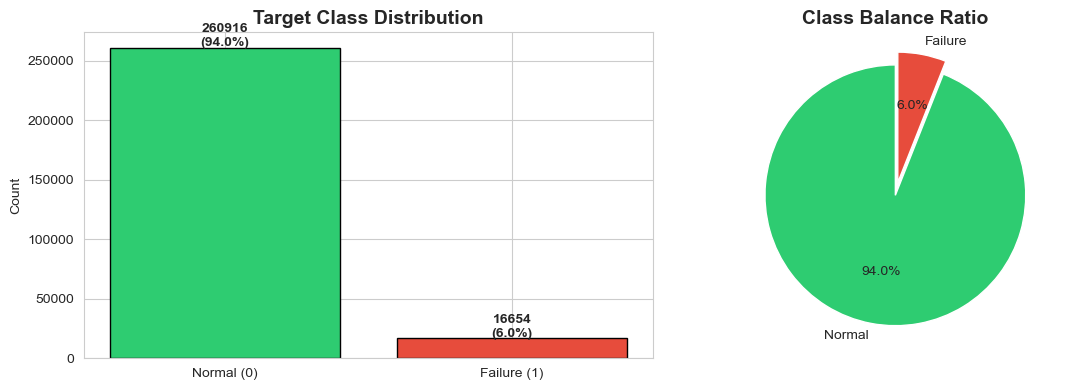

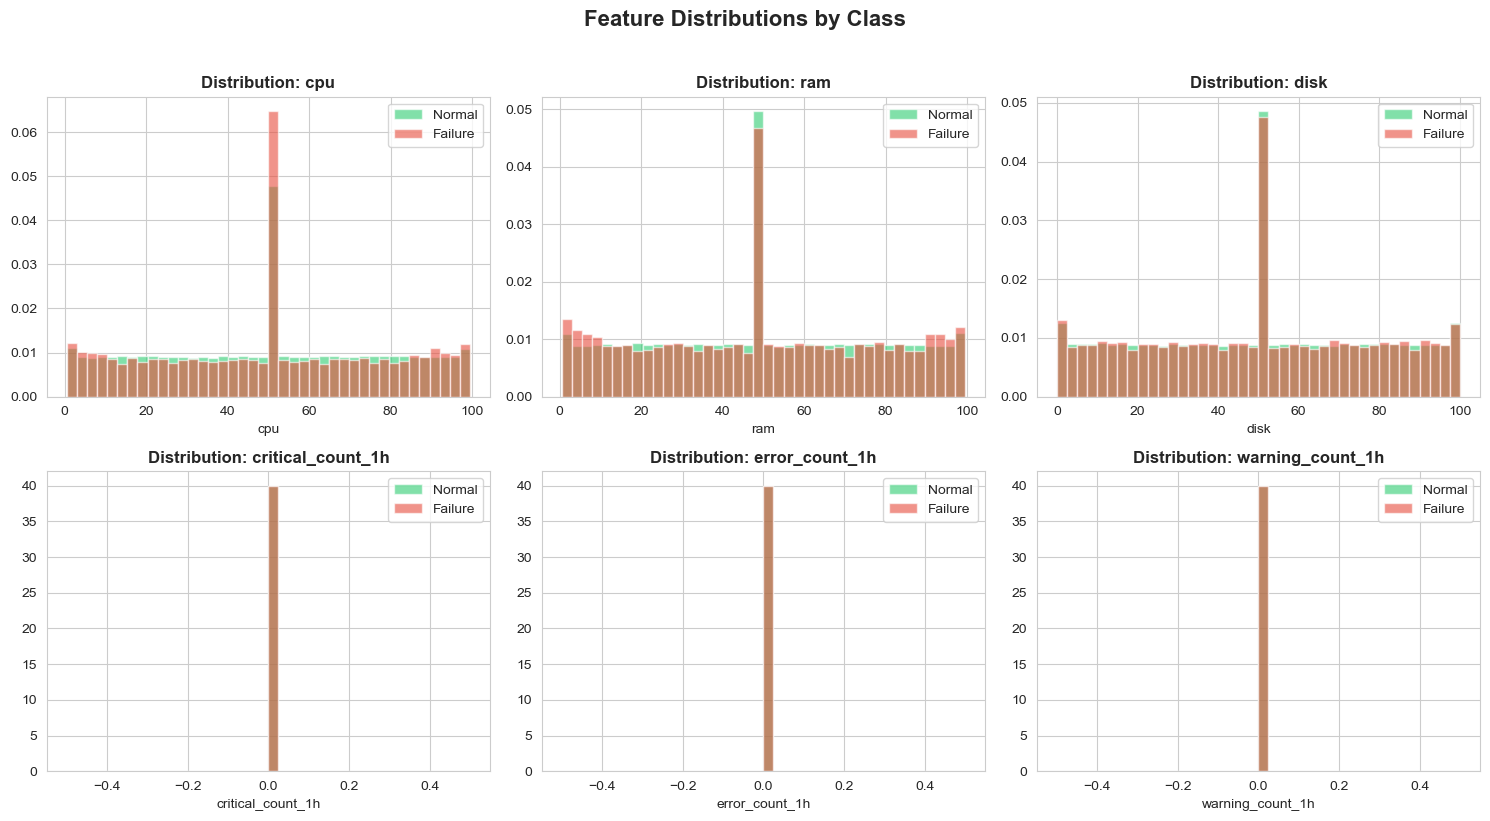

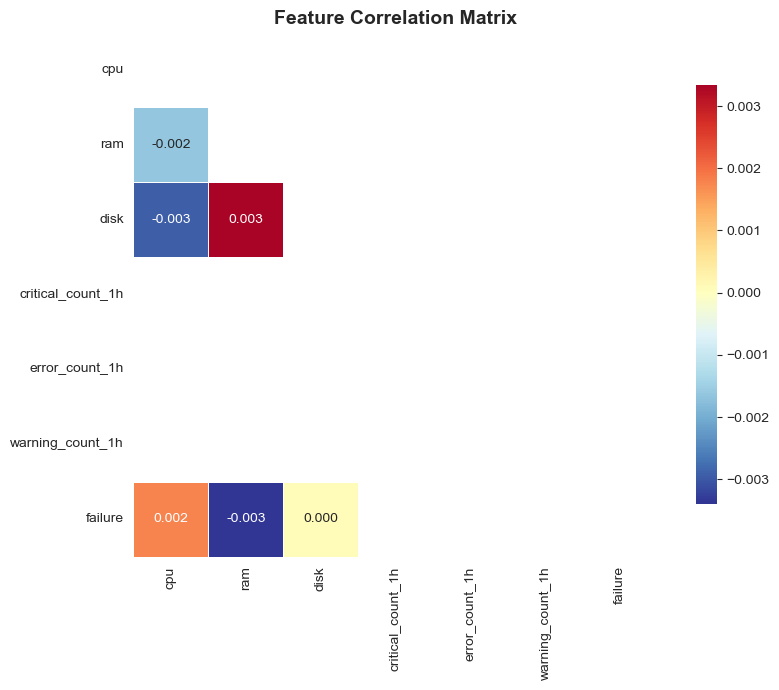

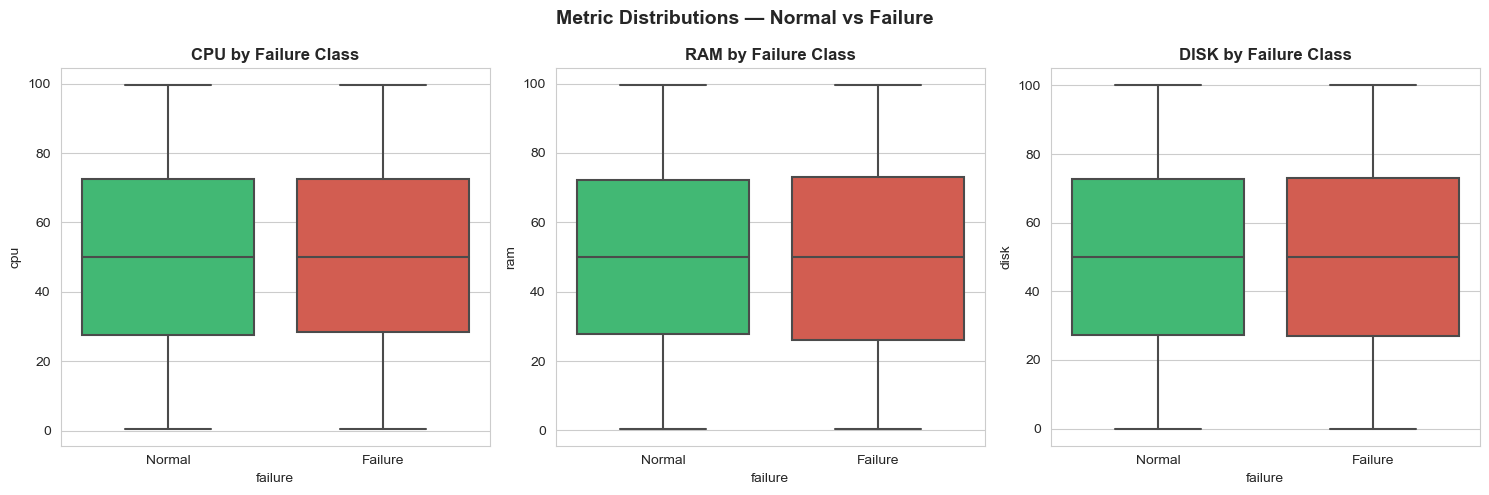

 Static visualizations complete


In [11]:
# ============================================================
# 9.1 EDA — Matplotlib & Seaborn
# ============================================================
y = df["failure"].astype(int)

# --- 9.1a: Class Balance ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts = y.value_counts().sort_index()
colors = ["#2ecc71", "#e74c3c"]
axes[0].bar(["Normal (0)", "Failure (1)"], counts.values, color=colors, edgecolor="black")
axes[0].set_title("Target Class Distribution", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + len(df)*0.005, f"{v}\n({v/len(df)*100:.1f}%)", ha="center", fontweight="bold")

# Pie chart
axes[1].pie(counts.values, labels=["Normal", "Failure"], autopct="%1.1f%%",
            colors=colors, startangle=90, explode=(0, 0.1))
axes[1].set_title("Class Balance Ratio", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# --- 9.1b: Feature Distributions by Class ---
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for idx, col in enumerate(FEATURES):
    ax = axes[idx // 3][idx % 3]
    for label, color, name in [(0, "#2ecc71", "Normal"), (1, "#e74c3c", "Failure")]:
        subset = df[df["failure"] == label][col]
        ax.hist(subset, bins=40, alpha=0.6, color=color, label=name, density=True)
    ax.set_title(f"Distribution: {col}", fontsize=12, fontweight="bold")
    ax.set_xlabel(col)
    ax.legend()
plt.suptitle("Feature Distributions by Class", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# --- 9.1c: Correlation Heatmap ---
fig, ax = plt.subplots(figsize=(9, 7))
# FIX: Pandas 1.4.x does not support numeric_only= in .corr()
# Select only numeric columns first, then call .corr()
corr = df[FEATURES + ["failure"]].select_dtypes(include=[np.number]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".3f", cmap="RdYlBu_r",
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# --- 9.1d: Box Plots by Class ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, col in enumerate(["cpu", "ram", "disk"]):
    # FIX: seaborn 0.11 — use hue= instead of palette dict with x=
    sns.boxplot(data=df, x="failure", y=col, ax=axes[idx],
                palette=["#2ecc71", "#e74c3c"])
    axes[idx].set_title(f"{col.upper()} by Failure Class", fontsize=12, fontweight="bold")
    axes[idx].set_xticklabels(["Normal", "Failure"])
plt.suptitle("Metric Distributions — Normal vs Failure", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(" Static visualizations complete")

### 9.2 — Interactive Visualizations (Plotly)


In [12]:
# ============================================================
# 9.2 EDA — Plotly Interactive Charts
# ============================================================
# Fix: Ensure nbformat is installed for Plotly rendering in Jupyter
try:
    import nbformat
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "nbformat"])
    import nbformat

import plotly.io as pio
pio.renderers.default = "notebook"

# Sample for Plotly to avoid RAM issues (8GB machine)
sample_size = min(5000, len(df))
df_plot = df.sort_values("timestamp").tail(sample_size).copy()
df_plot["failure_label"] = df_plot["failure"].map({0: "Normal", 1: "Failure"})

# --- 9.2a: CPU over time with failure markers ---
fig = px.scatter(df_plot, x="timestamp", y="cpu", color="failure_label",
                 color_discrete_map={"Normal": "#2ecc71", "Failure": "#e74c3c"},
                 title="CPU Usage Over Time (with Failure Markers)",
                 opacity=0.6, height=400)
fig.update_layout(xaxis_title="Time", yaxis_title="CPU Usage (%)")
fig.show()

# --- 9.2b: 3D scatter: CPU vs RAM vs Disk ---
fig = px.scatter_3d(df_plot.sample(min(2000, len(df_plot)), random_state=RANDOM_SEED),
                    x="cpu", y="ram", z="disk", color="failure_label",
                    color_discrete_map={"Normal": "#2ecc71", "Failure": "#e74c3c"},
                    title="3D Feature Space: CPU × RAM × Disk",
                    opacity=0.5, height=500)
fig.show()

# --- 9.2c: Parallel Coordinates ---
fig = px.parallel_coordinates(
    df_plot.sample(min(2000, len(df_plot)), random_state=RANDOM_SEED),
    dimensions=FEATURES, color="failure",
    color_continuous_scale=["#2ecc71", "#e74c3c"],
    title="Parallel Coordinates — Feature Relationships"
)
fig.show()

# --- 9.2d: Interactive Heatmap ---
# FIX: Recompute corr here so this cell works even if 9.1 was not run
corr = df[FEATURES + ["failure"]].select_dtypes(include=[np.number]).corr()
fig = go.Figure(data=go.Heatmap(
    z=corr.values, x=corr.columns.tolist(), y=corr.columns.tolist(),
    colorscale="RdYlBu_r", zmid=0, text=corr.values.round(3),
    texttemplate="%{text}", hovertemplate="x: %{x}<br>y: %{y}<br>corr: %{z:.3f}"
))
fig.update_layout(title="Interactive Correlation Heatmap", height=500, width=600)
fig.show()

# --- 9.2e: Time series — CPU + RAM + Disk ---
fig = make_subplots(rows=3, cols=1, shared_xaxes=True,
                    subplot_titles=("CPU Usage (%)", "RAM Usage (%)", "Disk Proxy (%)"))
for i, col in enumerate(["cpu", "ram", "disk"], 1):
    fig.add_trace(go.Scatter(x=df_plot["timestamp"], y=df_plot[col],
                             mode="lines", name=col.upper(),
                             line=dict(width=1)), row=i, col=1)
fig.update_layout(height=600, title_text="System Metrics Time Series", showlegend=True)
fig.show()

print(" Interactive Plotly visualizations complete")
del df_plot
free_mem()

 Interactive Plotly visualizations complete


---
## 10) Baseline Heuristic Model

A rule-based scoring function matching the Django `heuristic_risk` fallback.  
This provides an interpretable baseline to compare against ML models.


Baseline Heuristic ROC-AUC: 0.4993


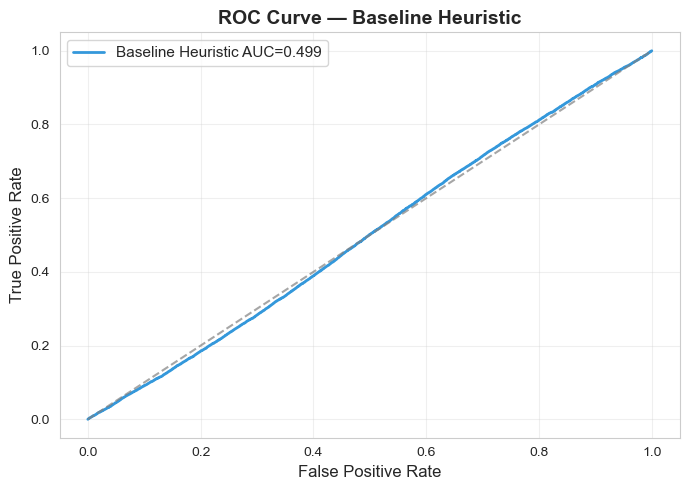

In [13]:
# ============================================================
# 10. Baseline Heuristic Risk Score
# ============================================================
def heuristic_score(row):
    """
    Rule-based risk scoring (matches Django heuristic_risk fallback).
    Weighted combination of normalized metrics and log counts.
    """
    cpu, ram, disk = row["cpu"], row["ram"], row["disk"]
    crit = row["critical_count_1h"]
    err  = row["error_count_1h"]
    warn = row["warning_count_1h"]

    score = 0.0
    score += min(cpu / 100.0, 1.0) * 0.35    # CPU weight: 35%
    score += min(ram / 100.0, 1.0) * 0.30    # RAM weight: 30%
    score += min(disk / 100.0, 1.0) * 0.15   # Disk weight: 15%
    score += min((crit * 0.15 + err * 0.08 + warn * 0.03), 1.0) * 0.20  # Logs: 20%
    return float(np.clip(score, 0, 1))

baseline_proba = df[FEATURES].apply(heuristic_score, axis=1).values
auc_baseline = roc_auc_score(y, baseline_proba)

print(f"Baseline Heuristic ROC-AUC: {auc_baseline:.4f}")

# Plot
fpr_b, tpr_b, _ = roc_curve(y, baseline_proba)
plt.figure(figsize=(7, 5))
plt.plot(fpr_b, tpr_b, linewidth=2, label=f"Baseline Heuristic AUC={auc_baseline:.3f}", color="#3498db")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.7)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve — Baseline Heuristic", fontsize=14, fontweight="bold")
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


---
## 11) Time-Indexed Train/Test Split

Use chronological split (80/20) to prevent data leakage, as recommended in the project specification and by Hadadi et al. (2024).


In [14]:
# ============================================================
# 11. Time-Indexed Split (80% train / 20% test)
# ============================================================
df_sorted = df.sort_values("timestamp").reset_index(drop=True)

cut = int(len(df_sorted) * 0.8)
train_df = df_sorted.iloc[:cut]
test_df  = df_sorted.iloc[cut:]

X_train = train_df[FEATURES].copy()
y_train = train_df["failure"].astype(int).copy()

X_test = test_df[FEATURES].copy()
y_test = test_df["failure"].astype(int).copy()

print(f"Train set: {X_train.shape[0]} rows | Failure rate: {y_train.mean():.4f}")
print(f"Test set:  {X_test.shape[0]} rows | Failure rate: {y_test.mean():.4f}")
print(f"\nTrain period: {train_df['timestamp'].min()} → {train_df['timestamp'].max()}")
print(f"Test period:  {test_df['timestamp'].min()} → {test_df['timestamp'].max()}")


Train set: 222056 rows | Failure rate: 0.0601
Test set:  55514 rows | Failure rate: 0.0598

Train period: 2023-01-01 00:00:00+00:00 → 2023-01-25 19:30:00+00:00
Test period:  2023-01-25 19:30:00+00:00 → 2023-01-31 23:59:00+00:00


---
## 12) Model Training — Initial Baseline Models

Train three models with class-balanced settings:
1. **Logistic Regression** — interpretable linear baseline
2. **Random Forest** — non-linear ensemble (limited to 200 trees for 8GB RAM)
3. **HistGradientBoosting** — efficient gradient boosting (native missing value support)


In [15]:
# ============================================================
# 12. Train Baseline Models
# ============================================================
models = {
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=800, class_weight="balanced",
            random_state=RANDOM_SEED
        ))
    ]),
    "RandomForest": Pipeline([
        ("clf", RandomForestClassifier(
            n_estimators=200,           # Reduced for 8GB RAM
            max_depth=12,               # Limit depth to save memory
            n_jobs=-1,
            class_weight="balanced_subsample",
            random_state=RANDOM_SEED
        ))
    ]),
    "HistGradientBoosting": Pipeline([
        ("clf", HistGradientBoostingClassifier(
            max_iter=200,               # Moderate for 8GB RAM
            max_depth=6,
            random_state=RANDOM_SEED
        ))
    ])
}

print("Training models...")
for name, model in models.items():
    print(f"  Training {name}...", end=" ")
    model.fit(X_train, y_train)
    print("")

# Predict probabilities
probas = {}
print("=" * 60)
print("BASELINE MODEL PERFORMANCE SUMMARY")
print("=" * 60)

results_list = []
for name, m in models.items():
    p = m.predict_proba(X_test)[:, 1]
    probas[name] = p
    auc  = roc_auc_score(y_test, p)
    ap   = average_precision_score(y_test, p)
    y_pred_05 = (p >= 0.5).astype(int)
    acc  = accuracy_score(y_test, y_pred_05)
    f1   = f1_score(y_test, y_pred_05)
    prec = precision_score(y_test, y_pred_05, zero_division=0)
    rec  = recall_score(y_test, y_pred_05, zero_division=0)
    results_list.append({
        "Model": name, "ROC-AUC": auc, "Avg Precision": ap,
        "Accuracy": acc, "F1": f1, "Precision": prec, "Recall": rec
    })
    print(f"  {name}: ROC-AUC={auc:.4f}  AP={ap:.4f}  F1={f1:.4f}")

results_df = pd.DataFrame(results_list).set_index("Model").round(4)
display(results_df)

free_mem()

Training models...
  Training LogisticRegression... 
  Training RandomForest... 
  Training HistGradientBoosting... 
BASELINE MODEL PERFORMANCE SUMMARY
  LogisticRegression: ROC-AUC=0.5026  AP=0.0648  F1=0.1061
  RandomForest: ROC-AUC=0.5404  AP=0.0788  F1=0.1263
  HistGradientBoosting: ROC-AUC=0.5419  AP=0.0800  F1=0.0000


,ROC-AUC,Avg Precision,Accuracy,F1,Precision,Recall
Model,,,,,,
LogisticRegression,0.5026,0.0648,0.4990,0.1061,0.0594,0.4971
RandomForest,0.5404,0.0788,0.8485,0.1263,0.0964,0.1832
HistGradientBoosting,0.5419,0.0800,0.9402,0.0000,0.0000,0.0000


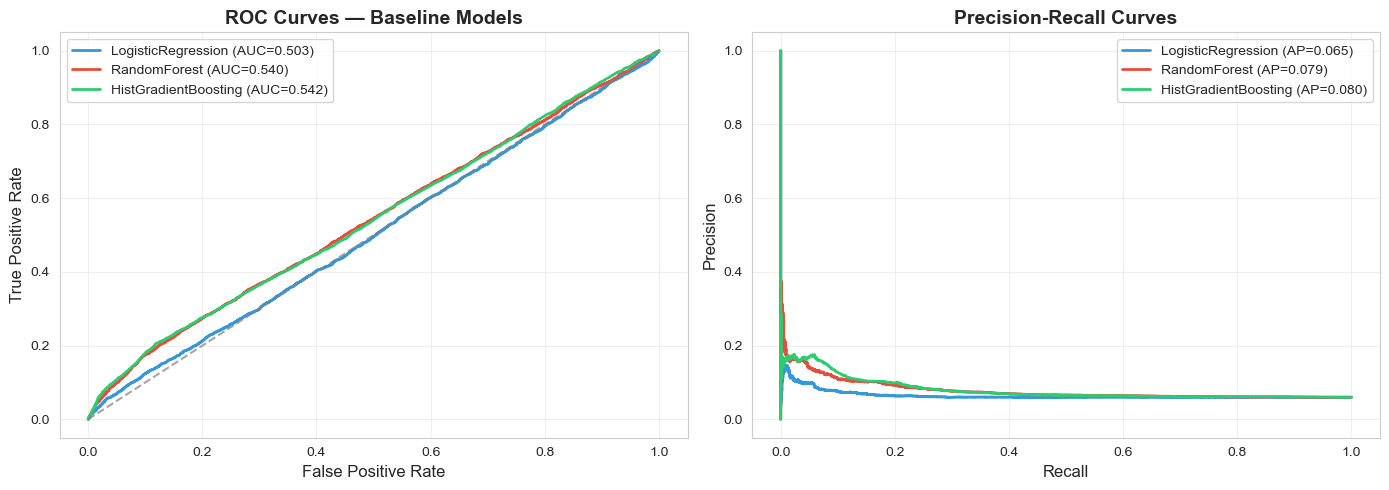

In [16]:
# ============================================================
# 12b. ROC & Precision-Recall Curves (Baseline Models)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ["#3498db", "#e74c3c", "#2ecc71"]

# ROC curves
for (name, p), color in zip(probas.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, p)
    auc = roc_auc_score(y_test, p)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=color, linewidth=2)
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.7)
axes[0].set_xlabel("False Positive Rate", fontsize=12)
axes[0].set_ylabel("True Positive Rate", fontsize=12)
axes[0].set_title("ROC Curves — Baseline Models", fontsize=14, fontweight="bold")
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# PR curves
for (name, p), color in zip(probas.items(), colors):
    precision, recall, _ = precision_recall_curve(y_test, p)
    ap = average_precision_score(y_test, p)
    axes[1].plot(recall, precision, label=f"{name} (AP={ap:.3f})", color=color, linewidth=2)
axes[1].set_xlabel("Recall", fontsize=12)
axes[1].set_ylabel("Precision", fontsize=12)
axes[1].set_title("Precision-Recall Curves", fontsize=14, fontweight="bold")
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


---
## 13) Hyperparameter Tuning (RandomizedSearchCV)

Time-series aware cross-validation using `TimeSeriesSplit` (falls back to `StratifiedKFold` if needed).  
**RAM-optimized:** Reduced `n_iter` and limited parallel jobs.


In [20]:
# ============================================================
# 13. Hyperparameter Tuning with RandomizedSearchCV
# ============================================================
def make_cv(y_tr, X_tr):
    """Create time-series CV; fallback to stratified if folds have 0 positives"""
    try:
        cv = TimeSeriesSplit(n_splits=5)
        for _, test_idx in cv.split(X_tr):
            if y_tr.iloc[test_idx].sum() == 0:
                raise ValueError("A fold has 0 positives")
        print("  Using TimeSeriesSplit (5 folds)")
        return cv
    except Exception:
        print("  Falling back to StratifiedKFold (5 folds)")
        return StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

cv = make_cv(y_train, X_train)

# Tuning parameter spaces (RAM-friendly ranges)
param_grids = {
    "LogisticRegression": {
        "clf__C": np.logspace(-3, 2, 10),
        "clf__solver": ["liblinear", "lbfgs"],
    },
    "RandomForest": {
        "clf__n_estimators": [150, 200, 300],
        "clf__max_depth": [6, 10, 14, None],
        "clf__min_samples_split": [2, 4, 8],
        "clf__min_samples_leaf": [1, 2, 4],
        "clf__max_features": ["sqrt", "log2"],
    },
    "HistGradientBoosting": {
        "clf__learning_rate": [0.02, 0.05, 0.1, 0.2],
        "clf__max_depth": [3, 5, 7, None],
        "clf__max_leaf_nodes": [15, 31, 63],
        "clf__min_samples_leaf": [10, 20, 40],
    }
}

searches = {}
for name, model in models.items():
    n_iter = 10 if name == "LogisticRegression" else 15
    print(f"\nTuning {name} ({n_iter} iterations)...")
    search = RandomizedSearchCV(
        model,
        param_distributions=param_grids[name],
        n_iter=n_iter,
        scoring="roc_auc",
        cv=cv,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        verbose=0
    )
    search.fit(X_train, y_train)
    searches[name] = search
    print(f"  Best CV AUC: {search.best_score_:.4f}")
    print(f"  Best params: {search.best_params_}")

free_mem()


  Using TimeSeriesSplit (5 folds)

Tuning LogisticRegression (10 iterations)...
  Best CV AUC: 0.4995
  Best params: {'clf__solver': 'lbfgs', 'clf__C': 0.001}

Tuning RandomForest (15 iterations)...
  Best CV AUC: 0.5442
  Best params: {'clf__n_estimators': 150, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 2, 'clf__max_features': 'sqrt', 'clf__max_depth': 6}

Tuning HistGradientBoosting (15 iterations)...
  Best CV AUC: 0.5467
  Best params: {'clf__min_samples_leaf': 20, 'clf__max_leaf_nodes': 15, 'clf__max_depth': None, 'clf__learning_rate': 0.1}


---
## 14) Model Evaluation — Tuned Models

Comprehensive evaluation of tuned models:
- ROC-AUC curves
- Confusion matrices
- Classification reports
- Operational metrics (False Alarm Rate, Miss Rate)


In [21]:
# ============================================================
# 14. Evaluate Tuned Models
# ============================================================
best_estimators = {name: s.best_estimator_ for name, s in searches.items()}
test_probas = {name: est.predict_proba(X_test)[:, 1] for name, est in best_estimators.items()}

print("=" * 60)
print("TUNED MODEL PERFORMANCE SUMMARY")
print("=" * 60)

results_list = []
for name, p in test_probas.items():
    auc = roc_auc_score(y_test, p)
    ap  = average_precision_score(y_test, p)
    y_pred_05 = (p >= 0.5).astype(int)
    acc = accuracy_score(y_test, y_pred_05)
    f1  = f1_score(y_test, y_pred_05)
    prec = precision_score(y_test, y_pred_05, zero_division=0)
    rec  = recall_score(y_test, y_pred_05, zero_division=0)
    results_list.append({
        "Model": name, "ROC-AUC": auc, "Avg Precision": ap,
        "Accuracy": acc, "F1": f1, "Precision": prec, "Recall": rec
    })
    print(f"  {name}: ROC-AUC={auc:.4f}  AP={ap:.4f}  F1={f1:.4f}")

results_df = pd.DataFrame(results_list).set_index("Model").round(4)
display(results_df)


TUNED MODEL PERFORMANCE SUMMARY
  LogisticRegression: ROC-AUC=0.5026  AP=0.0648  F1=0.1061
  RandomForest: ROC-AUC=0.5454  AP=0.0823  F1=0.1309
  HistGradientBoosting: ROC-AUC=0.5464  AP=0.0802  F1=0.0000


,ROC-AUC,Avg Precision,Accuracy,F1,Precision,Recall
Model,,,,,,
LogisticRegression,0.5026,0.0648,0.4989,0.1061,0.0594,0.4971
RandomForest,0.5454,0.0823,0.8206,0.1309,0.0921,0.2260
HistGradientBoosting,0.5464,0.0802,0.9402,0.0000,0.0000,0.0000


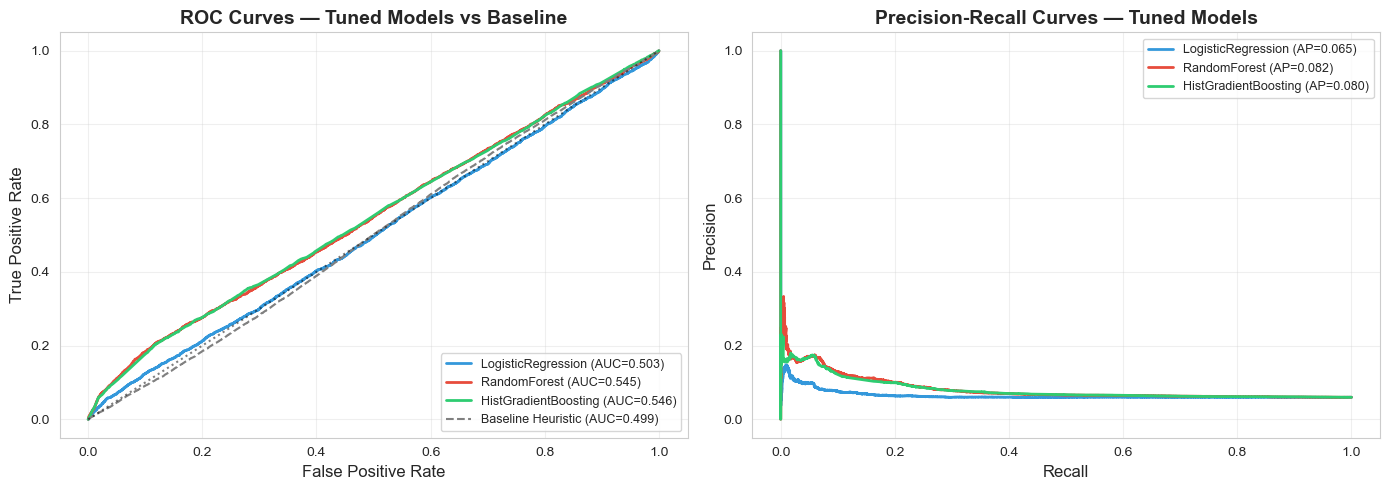

In [22]:
# ============================================================
# 14b. ROC Curves — Tuned Models (Publication Quality)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {"LogisticRegression": "#3498db", "RandomForest": "#e74c3c", "HistGradientBoosting": "#2ecc71"}

# ROC
for name, p in test_probas.items():
    fpr, tpr, _ = roc_curve(y_test, p)
    auc = roc_auc_score(y_test, p)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=colors[name], linewidth=2)

# Add baseline heuristic for comparison
fpr_b, tpr_b, _ = roc_curve(y, baseline_proba)
axes[0].plot(fpr_b, tpr_b, label=f"Baseline Heuristic (AUC={auc_baseline:.3f})",
             color="gray", linewidth=1.5, linestyle="--")
axes[0].plot([0, 1], [0, 1], linestyle=":", color="black", alpha=0.5)
axes[0].set_xlabel("False Positive Rate", fontsize=12)
axes[0].set_ylabel("True Positive Rate", fontsize=12)
axes[0].set_title("ROC Curves — Tuned Models vs Baseline", fontsize=14, fontweight="bold")
axes[0].legend(fontsize=9, loc="lower right")
axes[0].grid(alpha=0.3)

# Precision-Recall
for name, p in test_probas.items():
    precision, recall, _ = precision_recall_curve(y_test, p)
    ap = average_precision_score(y_test, p)
    axes[1].plot(recall, precision, label=f"{name} (AP={ap:.3f})", color=colors[name], linewidth=2)
axes[1].set_xlabel("Recall", fontsize=12)
axes[1].set_ylabel("Precision", fontsize=12)
axes[1].set_title("Precision-Recall Curves — Tuned Models", fontsize=14, fontweight="bold")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


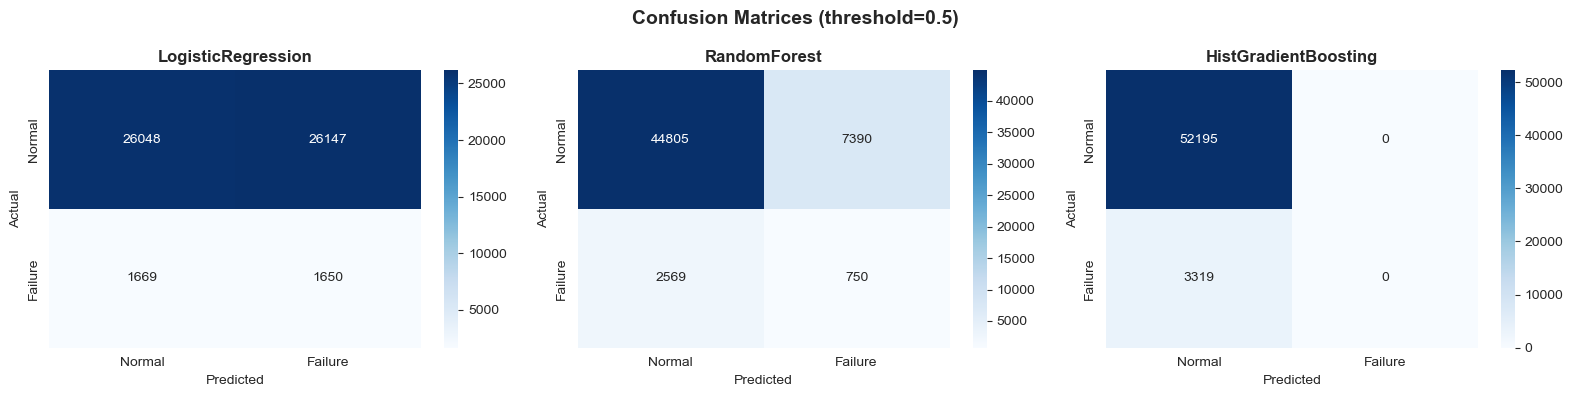


🏆 Best model: HistGradientBoosting (ROC-AUC: 0.5464)


In [23]:
# ============================================================
# 14c. Confusion Matrices — Tuned Models
# ============================================================
best_name = max(test_probas, key=lambda k: roc_auc_score(y_test, test_probas[k]))
best_model = best_estimators[best_name]
best_proba = test_probas[best_name]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for idx, (name, p) in enumerate(test_probas.items()):
    y_pred = (p >= 0.5).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[idx],
                xticklabels=["Normal", "Failure"], yticklabels=["Normal", "Failure"])
    axes[idx].set_title(f"{name}", fontsize=12, fontweight="bold")
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")
plt.suptitle("Confusion Matrices (threshold=0.5)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\n🏆 Best model: {best_name} (ROC-AUC: {roc_auc_score(y_test, best_proba):.4f})")


---
## 15) Threshold Analysis & Operational Metrics

Evaluate the best model across multiple thresholds to find the optimal operating point.  
Your Django app uses: `≥ 0.7` = HIGH, `≥ 0.4` = MEDIUM, else LOW.


Threshold Analysis for Best Model: HistGradientBoosting


,Threshold,Precision,Recall,F1,FalseAlarmRate(FPR),MissRate(FNR),FP,FN
0,0.05,0.060,0.988,0.113,0.987,0.012,51510,41
1,0.10,0.166,0.061,0.090,0.020,0.939,1026,3115
2,0.15,0.165,0.044,0.069,0.014,0.956,737,3173
3,0.20,0.171,0.002,0.004,0.001,0.998,29,3313
11,0.60,0.000,0.000,0.000,0.000,1.000,0,3319
17,0.90,0.000,0.000,0.000,0.000,1.000,0,3319
16,0.85,0.000,0.000,0.000,0.000,1.000,0,3319
15,0.80,0.000,0.000,0.000,0.000,1.000,0,3319
14,0.75,0.000,0.000,0.000,0.000,1.000,0,3319
13,0.70,0.000,0.000,0.000,0.000,1.000,0,3319



 Optimal threshold (max F1): 0.05

Classification Report at threshold = 0.05:
              precision    recall  f1-score   support

      Normal      0.944     0.013     0.026     52195
     Failure      0.060     0.988     0.113      3319

    accuracy                          0.071     55514
   macro avg      0.502     0.500     0.069     55514
weighted avg      0.891     0.071     0.031     55514



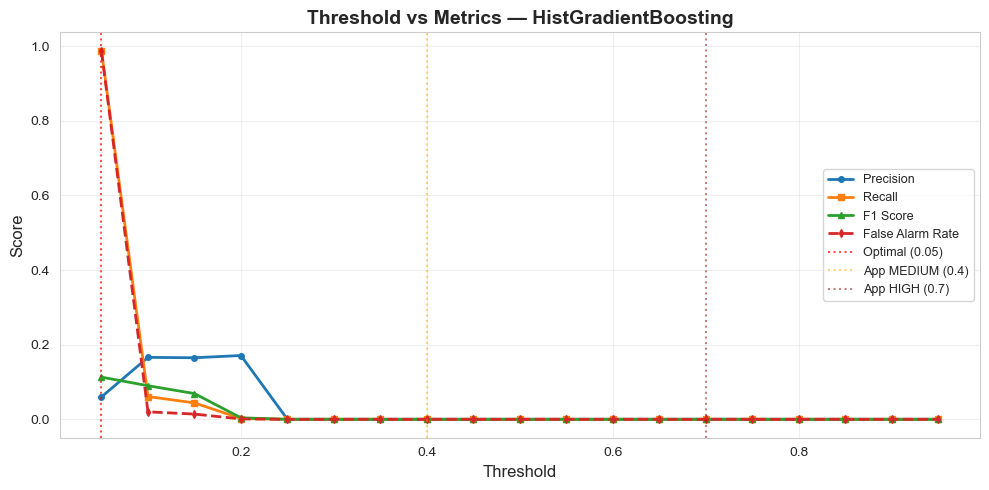

In [24]:
# ============================================================
# 15. Threshold Analysis
# ============================================================
def threshold_table(y_true, proba, thresholds=np.linspace(0.05, 0.95, 19)):
    rows = []
    for thr in thresholds:
        pred = (proba >= thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
        precision = tp / (tp + fp) if (tp + fp) else 0
        recall = tp / (tp + fn) if (tp + fn) else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0
        fpr = fp / (fp + tn) if (fp + tn) else 0
        fnr = fn / (fn + tp) if (fn + tp) else 0
        rows.append((round(thr, 2), round(precision, 3), round(recall, 3),
                      round(f1, 3), round(fpr, 3), round(fnr, 3), fp, fn))
    return pd.DataFrame(rows, columns=["Threshold", "Precision", "Recall", "F1",
                                        "FalseAlarmRate(FPR)", "MissRate(FNR)", "FP", "FN"])

tab = threshold_table(y_test, best_proba)
tab_sorted = tab.sort_values("F1", ascending=False)

print(f"Threshold Analysis for Best Model: {best_name}")
print("=" * 80)
display(tab_sorted.head(10))

best_thr = float(tab_sorted.iloc[0]["Threshold"])
print(f"\n Optimal threshold (max F1): {best_thr}")

# Apply optimal threshold
y_pred_opt = (best_proba >= best_thr).astype(int)
print(f"\nClassification Report at threshold = {best_thr}:")
print(classification_report(y_test, y_pred_opt, digits=3,
                            target_names=["Normal", "Failure"]))

# Threshold plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(tab["Threshold"], tab["Precision"], label="Precision", linewidth=2, marker="o", markersize=4)
ax.plot(tab["Threshold"], tab["Recall"], label="Recall", linewidth=2, marker="s", markersize=4)
ax.plot(tab["Threshold"], tab["F1"], label="F1 Score", linewidth=2, marker="^", markersize=4)
ax.plot(tab["Threshold"], tab["FalseAlarmRate(FPR)"], label="False Alarm Rate", linewidth=2,
        linestyle="--", marker="d", markersize=4)
ax.axvline(x=best_thr, color="red", linestyle=":", alpha=0.7, label=f"Optimal ({best_thr})")
ax.axvline(x=0.4, color="orange", linestyle=":", alpha=0.5, label="App MEDIUM (0.4)")
ax.axvline(x=0.7, color="darkred", linestyle=":", alpha=0.5, label="App HIGH (0.7)")
ax.set_xlabel("Threshold", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title(f"Threshold vs Metrics — {best_name}", fontsize=14, fontweight="bold")
ax.legend(fontsize=9, loc="center right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


---
## 16) Explainable AI — SHAP (SHapley Additive exPlanations)

SHAP provides both **global** feature importance and **local** instance-level explanations.  
This satisfies PreventaB's XAI requirement (Lundberg & Lee, 2017).

### 16.1 — Global SHAP Analysis


Best model: HistGradientBoosting
Explaining with SHAP on 1000 samples...

📊 SHAP Summary Plot (Global Feature Importance)


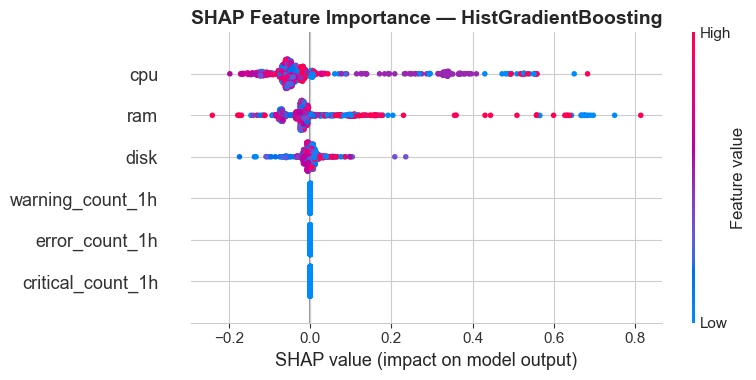


📊 SHAP Mean Absolute Impact


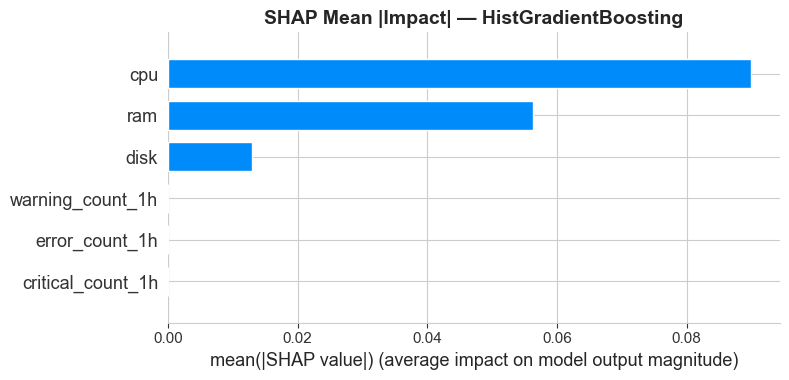

In [26]:
# ============================================================
# 16.1 SHAP — Global Feature Importance
# ============================================================
# Sample for SHAP (RAM-friendly: max 1000 samples)
shap_sample_size = min(1000, len(X_test))
X_explain = X_test.sample(shap_sample_size, random_state=RANDOM_SEED)

# Unwrap the classifier from the pipeline
est = best_model.named_steps.get("clf", best_model)

print(f"Best model: {best_name}")
print(f"Explaining with SHAP on {shap_sample_size} samples...")

if isinstance(est, (RandomForestClassifier, HistGradientBoostingClassifier)):
    explainer = shap.TreeExplainer(est)
    shap_values = explainer.shap_values(X_explain)
    # Binary classification may return list [class_0, class_1]
    if isinstance(shap_values, list):
        sv = shap_values[1]
    else:
        sv = shap_values
else:
    # Logistic Regression: use KernelExplainer with small background
    background = shap.sample(X_train, min(100, len(X_train)))
    explainer = shap.KernelExplainer(best_model.predict_proba, background)
    shap_values = explainer.shap_values(X_explain, nsamples=100)
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values

# --- Global Summary Plot ---
print("\n📊 SHAP Summary Plot (Global Feature Importance)")
shap.summary_plot(sv, X_explain, show=False)
plt.title(f"SHAP Feature Importance — {best_name}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# --- Bar Plot ---
print("\n📊 SHAP Mean Absolute Impact")
shap.summary_plot(sv, X_explain, plot_type="bar", show=False)
plt.title(f"SHAP Mean |Impact| — {best_name}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### 16.2 — Local SHAP Explanations (Individual Predictions)

Explain specific predictions to understand why the model flagged a particular system state.



Local SHAP Explanation — HIGH RISK Sample
Predicted probability: 0.2296
Feature values: {'cpu': 5.404636691, 'ram': 97.99597812, 'disk': 55.70745201756048, 'critical_count_1h': 0.0, 'error_count_1h': 0.0, 'warning_count_1h': 0.0}
  Waterfall plot error: index 1 is out of bounds for axis 0 with size 1


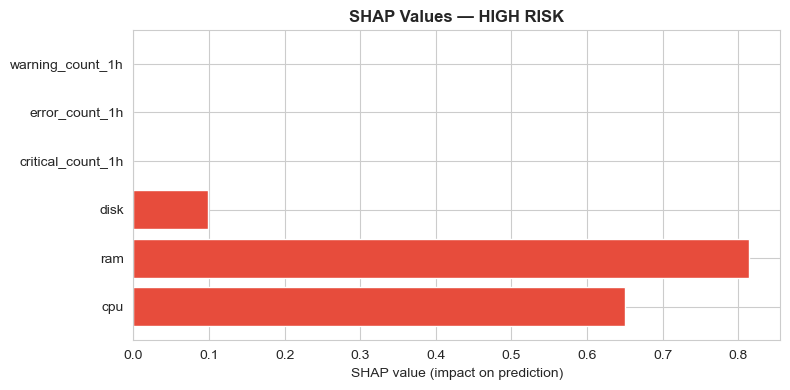


Local SHAP Explanation — LOW RISK Sample
Predicted probability: 0.0437
Feature values: {'cpu': 84.49446234, 'ram': 99.45539157, 'disk': 50.06434553801227, 'critical_count_1h': 0.0, 'error_count_1h': 0.0, 'warning_count_1h': 0.0}
  Waterfall plot error: index 1 is out of bounds for axis 0 with size 1


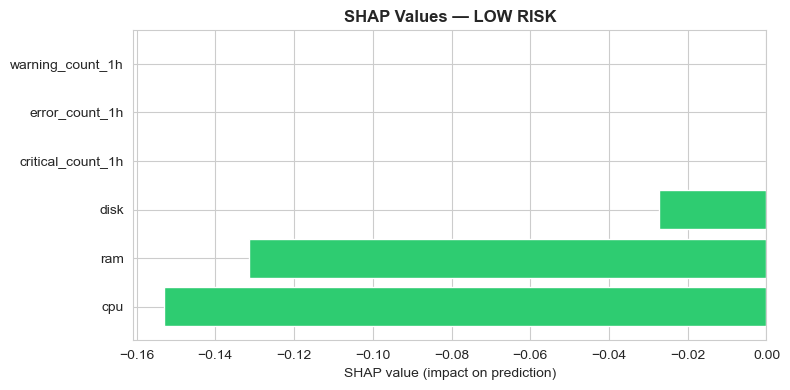

In [27]:
# ============================================================
# 16.2 SHAP — Local Explanations
# ============================================================
# Find interesting samples: one high-risk, one low-risk
probas_explain = best_model.predict_proba(X_explain)[:, 1]

high_risk_idx = np.argmax(probas_explain)
low_risk_idx  = np.argmin(probas_explain)

for label, idx in [("HIGH RISK", high_risk_idx), ("LOW RISK", low_risk_idx)]:
    print(f"\n{'='*50}")
    print(f"Local SHAP Explanation — {label} Sample")
    print(f"{'='*50}")
    print(f"Predicted probability: {probas_explain[idx]:.4f}")
    print(f"Feature values: {dict(X_explain.iloc[idx])}")

    # Waterfall plot
    try:
        base_val = explainer.expected_value
        if isinstance(base_val, (list, np.ndarray)):
            base_val = base_val[1]
        shap_exp = shap.Explanation(
            values=sv[idx],
            base_values=base_val,
            data=X_explain.iloc[idx].values,
            feature_names=FEATURES
        )
        shap.plots.waterfall(shap_exp, show=False)
        plt.title(f"SHAP Waterfall — {label}", fontsize=12, fontweight="bold")
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"  Waterfall plot error: {e}")
        # Fallback: manual bar chart
        fig, ax = plt.subplots(figsize=(8, 4))
        colors = ["#e74c3c" if v > 0 else "#2ecc71" for v in sv[idx]]
        ax.barh(FEATURES, sv[idx], color=colors)
        ax.set_title(f"SHAP Values — {label}", fontsize=12, fontweight="bold")
        ax.set_xlabel("SHAP value (impact on prediction)")
        plt.tight_layout()
        plt.show()

free_mem()


---
## 17) Explainable AI — LIME (Local Interpretable Model-agnostic Explanations)

LIME approximates the model's behavior locally around a single prediction using a simple interpretable model (Ribeiro, Singh & Guestrin, 2016).



LIME Explanation — HIGH RISK
Predicted probability: 0.2296

Top contributing features:
  50.06 < disk <= 72.87: +0.0046 (↑ increases risk)
  ram > 72.28: +0.0008 (↑ increases risk)
  cpu <= 27.63: -0.0001 (↓ decreases risk)
  critical_count_1h <= 0.00: +0.0000 (↓ decreases risk)
  error_count_1h <= 0.00: +0.0000 (↓ decreases risk)
  warning_count_1h <= 0.00: +0.0000 (↓ decreases risk)


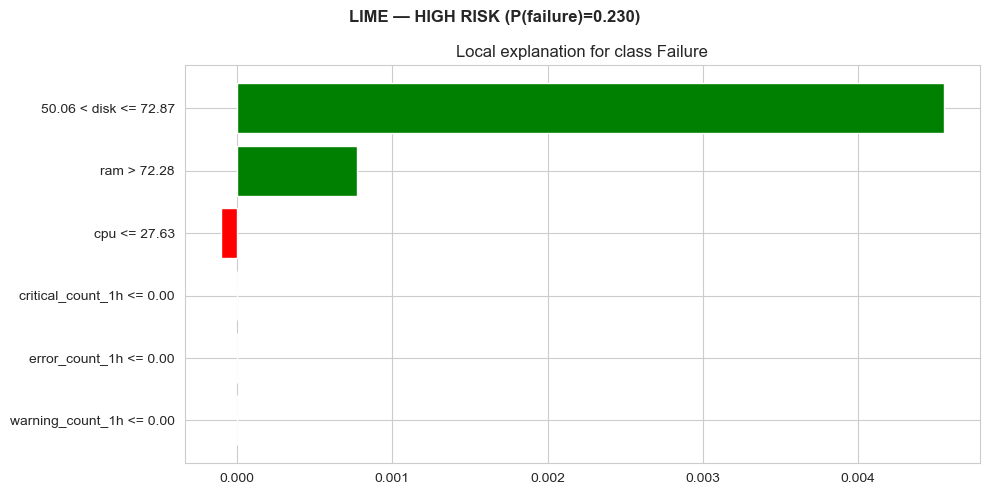


LIME Explanation — LOW RISK
Predicted probability: 0.0437

Top contributing features:
  cpu > 72.34: +0.0038 (↑ increases risk)
  ram > 72.28: -0.0011 (↓ decreases risk)
  27.24 < disk <= 50.06: -0.0009 (↓ decreases risk)
  critical_count_1h <= 0.00: +0.0000 (↓ decreases risk)
  error_count_1h <= 0.00: +0.0000 (↓ decreases risk)
  warning_count_1h <= 0.00: +0.0000 (↓ decreases risk)


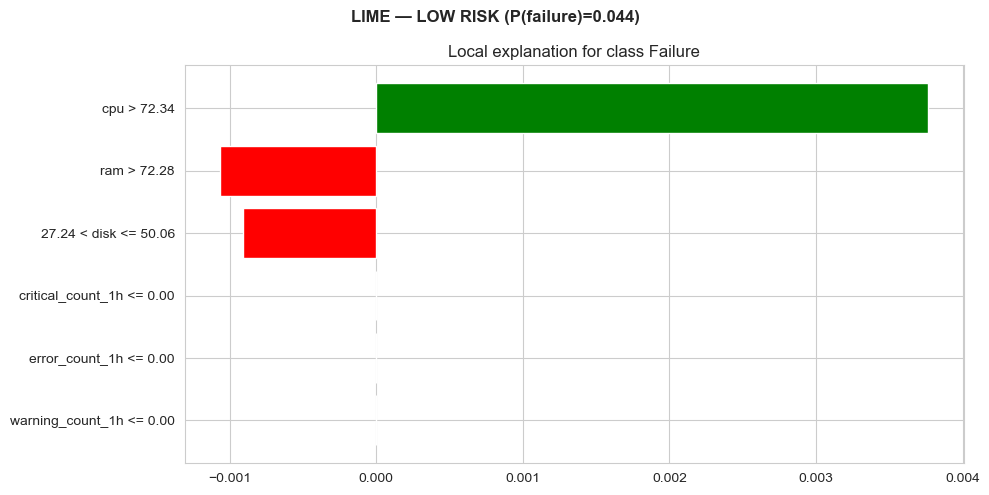


 LIME explanations complete


In [28]:
# ============================================================
# 17. LIME Explanations
# ============================================================
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=FEATURES,
    class_names=["Normal", "Failure"],
    mode="classification",
    random_state=RANDOM_SEED,
    discretize_continuous=True
)

# Explain a high-risk and low-risk sample
for label, idx in [("HIGH RISK", high_risk_idx), ("LOW RISK", low_risk_idx)]:
    print(f"\n{'='*50}")
    print(f"LIME Explanation — {label}")
    print(f"{'='*50}")

    instance = X_explain.iloc[idx].values
    explanation = lime_explainer.explain_instance(
        instance,
        best_model.predict_proba,
        num_features=len(FEATURES),
        num_samples=500          # Reduced for 8GB RAM
    )

    print(f"Predicted probability: {probas_explain[idx]:.4f}")
    print(f"\nTop contributing features:")
    for feat, weight in explanation.as_list():
        direction = "↑ increases risk" if weight > 0 else "↓ decreases risk"
        print(f"  {feat}: {weight:+.4f} ({direction})")

    # LIME plot
    fig = explanation.as_pyplot_figure()
    fig.suptitle(f"LIME — {label} (P(failure)={probas_explain[idx]:.3f})",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

print("\n LIME explanations complete")
free_mem()


---
## 18) Recommendations & Action Mapping

Generate plain-English explanations and preventive actions based on SHAP feature attributions.  
This maps model outputs to actionable guidance for administrators — a core PreventaB requirement.


SAMPLE RECOMMENDATIONS (PreventaB Action Mapping)

──────────────────────────────────────────────────────────────────────
  System State: HIGH RISK | P(failure) = 0.230
──────────────────────────────────────────────────────────────────────

  ⚠️  Risk Factor 1: RAM
      Current value: 98.0
      Impact score: +0.8146
      Explanation: Memory usage is high, suggesting potential memory pressure or leaks.
      Recommended actions:
        → Investigate memory-intensive applications for leaks
        → Check if virtual memory (swap) is being heavily used

  ⚠️  Risk Factor 2: CPU
      Current value: 5.4
      Impact score: +0.6506
      Explanation: CPU utilization is elevated, indicating heavy processing load.
      Recommended actions:
        → Check for runaway processes or stuck applications
        → Review scheduled tasks for overlapping execution windows

  ⚠️  Risk Factor 3: DISK
      Current value: 55.71
      Impact score: +0.0981
      Explanation: Disk usage/activity is e

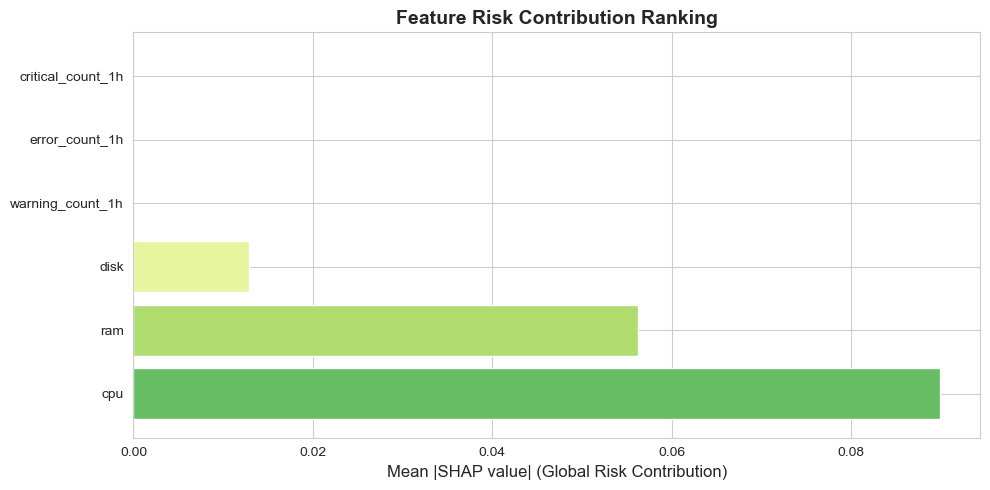


 Recommendations engine validated


In [29]:
# ============================================================
# 18. Recommendation Engine & Action Mapping
# ============================================================

# Action mapping: feature -> explanation template + prevention action
ACTION_MAP = {
    "cpu": {
        "high_explanation": "CPU utilization is elevated, indicating heavy processing load.",
        "actions": [
            "Check for runaway processes or stuck applications",
            "Review scheduled tasks for overlapping execution windows",
            "Consider load balancing or scaling compute resources",
            "Monitor for cryptomining or unauthorized software"
        ]
    },
    "ram": {
        "high_explanation": "Memory usage is high, suggesting potential memory pressure or leaks.",
        "actions": [
            "Investigate memory-intensive applications for leaks",
            "Check if virtual memory (swap) is being heavily used",
            "Consider adding physical RAM or optimizing applications",
            "Restart long-running services to release accumulated memory"
        ]
    },
    "disk": {
        "high_explanation": "Disk usage/activity is elevated, which may indicate storage saturation.",
        "actions": [
            "Clean up temporary files, logs, and old backups",
            "Check disk health with SMART diagnostics",
            "Verify no runaway logging is filling disk space",
            "Plan storage expansion if consistently above 85%"
        ]
    },
    "critical_count_1h": {
        "high_explanation": "Multiple critical events detected in recent logs.",
        "actions": [
            "Immediately review critical event details in Event Viewer",
            "Check for hardware failures (disk, memory, power)",
            "Verify system service health and restart if needed",
            "Escalate to senior administrator if pattern persists"
        ]
    },
    "error_count_1h": {
        "high_explanation": "Elevated error events detected, indicating recurring issues.",
        "actions": [
            "Review error logs to identify common error codes",
            "Check application dependencies and configurations",
            "Update drivers and apply pending patches",
            "Test network connectivity and DNS resolution"
        ]
    },
    "warning_count_1h": {
        "high_explanation": "Warning events are above normal, suggesting emerging issues.",
        "actions": [
            "Review warning patterns for early degradation signs",
            "Check resource thresholds that may be triggering warnings",
            "Proactively address warnings before they become errors",
            "Document patterns for future baseline comparison"
        ]
    }
}

def generate_recommendation(shap_values_row, feature_values, features, threshold=0.01):
    """Generate plain-English recommendations from SHAP values."""
    recommendations = []
    # Sort features by absolute SHAP impact (descending)
    impacts = sorted(zip(features, shap_values_row, feature_values),
                     key=lambda x: abs(x[1]), reverse=True)

    for feat, shap_val, feat_val in impacts:
        if abs(shap_val) < threshold:
            continue
        if shap_val > 0 and feat in ACTION_MAP:  # Risk-increasing features
            rec = {
                "feature": feat,
                "value": round(float(feat_val), 2),
                "shap_impact": round(float(shap_val), 4),
                "explanation": ACTION_MAP[feat]["high_explanation"],
                "actions": ACTION_MAP[feat]["actions"][:2]  # Top 2 actions
            }
            recommendations.append(rec)
    return recommendations

# --- Demo: Generate recommendations for sample predictions ---
print("=" * 70)
print("SAMPLE RECOMMENDATIONS (PreventaB Action Mapping)")
print("=" * 70)

for label, idx in [("HIGH RISK", high_risk_idx), ("LOW RISK", low_risk_idx)]:
    print(f"\n{'─'*70}")
    print(f"  System State: {label} | P(failure) = {probas_explain[idx]:.3f}")
    print(f"{'─'*70}")

    recs = generate_recommendation(sv[idx], X_explain.iloc[idx].values, FEATURES)

    if not recs:
        print("   No significant risk factors identified. System appears healthy.")
    else:
        for i, rec in enumerate(recs, 1):
            print(f"\n  ⚠️  Risk Factor {i}: {rec['feature'].upper()}")
            print(f"      Current value: {rec['value']}")
            print(f"      Impact score: {rec['shap_impact']:+.4f}")
            print(f"      Explanation: {rec['explanation']}")
            print(f"      Recommended actions:")
            for action in rec['actions']:
                print(f"        → {action}")

# --- Summary visualization ---
fig, ax = plt.subplots(figsize=(10, 5))
mean_abs_shap = np.abs(sv).mean(axis=0)
sorted_idx = np.argsort(mean_abs_shap)[::-1]
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(FEATURES)))
ax.barh([FEATURES[i] for i in sorted_idx], mean_abs_shap[sorted_idx],
        color=colors)
ax.set_xlabel("Mean |SHAP value| (Global Risk Contribution)", fontsize=12)
ax.set_title("Feature Risk Contribution Ranking", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n Recommendations engine validated")


---
## 19) Export ML Artifacts for Django Integration

Export the trained model (`.joblib`), feature list (`.json`), and metadata (`.json`) to:  
`C:\\Users\\Bibash Shrestha\\Desktop\\Production Project\\Product\\ml_artifacts`

These artifacts are consumed by the PreventaB Django web application.


In [30]:
# ============================================================
# 19 A. Export Artifacts to Windows Path
# ============================================================
import datetime

# Target directory on your Windows machine
ARTIFACT_DIR = r"C:\Users\Bibash Shrestha\Desktop\Production Project\Product\ml_artifacts"

# Create directory if it doesn't exist
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# File paths
model_path    = os.path.join(ARTIFACT_DIR, "model.joblib")
features_path = os.path.join(ARTIFACT_DIR, "features.json")
meta_path     = os.path.join(ARTIFACT_DIR, "model_metadata.json")
actions_path  = os.path.join(ARTIFACT_DIR, "action_map.json")

# 1) Save trained model
joblib.dump(best_model, model_path, compress=3)
print(f" Model saved: {model_path}")
print(f"   Size: {os.path.getsize(model_path) / (1024*1024):.2f} MB")

# 2) Save feature list
with open(features_path, "w", encoding="utf-8") as f:
    json.dump(FEATURES, f, indent=2)
print(f" Features saved: {features_path}")

# 3) Save model metadata
meta = {
    "project": "PreventaB",
    "student": "Bibash Shrestha",
    "student_id": "77466887",
    "dataset_cloud_handle": CLOUD_DATASET_HANDLE,
    "dataset_windows_logs_handle": WINDOWS_LOGS_HANDLE,
    "selected_model": best_name,
    "model_type": str(type(est).__name__),
    "features": FEATURES,
    "n_features": len(FEATURES),
    "training_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
    "roc_auc_test": round(float(roc_auc_score(y_test, best_proba)), 4),
    "average_precision_test": round(float(average_precision_score(y_test, best_proba)), 4),
    "suggested_threshold_max_f1": round(float(best_thr), 3),
    "risk_labels": {
        "HIGH": ">= 0.7",
        "MEDIUM": ">= 0.4",
        "LOW": "< 0.4"
    },
    "best_params": searches[best_name].best_params_,
    "all_model_results": {
        name: {
            "roc_auc": round(float(roc_auc_score(y_test, test_probas[name])), 4),
            "avg_precision": round(float(average_precision_score(y_test, test_probas[name])), 4)
        }
        for name in test_probas
    },
    "created_utc": datetime.datetime.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ"),
    "python_version": sys.version,
    "scikit_learn_version": __import__("sklearn").__version__
}

with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2, default=str)
print(f" Metadata saved: {meta_path}")

# 4) Save action map for Django
with open(actions_path, "w", encoding="utf-8") as f:
    json.dump(ACTION_MAP, f, indent=2)
print(f" Action map saved: {actions_path}")

# --- Summary ---
print("\n" + "=" * 60)
print("EXPORT SUMMARY")
print("=" * 60)
print(f"Directory: {ARTIFACT_DIR}")
print(f"Files exported:")
for fpath in [model_path, features_path, meta_path, actions_path]:
    size = os.path.getsize(fpath) / 1024
    print(f"  📁 {os.path.basename(fpath)} ({size:.1f} KB)")
print(f"\nBest model: {best_name}")
print(f"ROC-AUC: {meta['roc_auc_test']}")
print(f"Optimal threshold: {meta['suggested_threshold_max_f1']}")


 Model saved: C:\Users\Bibash Shrestha\Desktop\Production Project\Product\ml_artifacts\model.joblib
   Size: 0.03 MB
 Features saved: C:\Users\Bibash Shrestha\Desktop\Production Project\Product\ml_artifacts\features.json
 Metadata saved: C:\Users\Bibash Shrestha\Desktop\Production Project\Product\ml_artifacts\model_metadata.json
 Action map saved: C:\Users\Bibash Shrestha\Desktop\Production Project\Product\ml_artifacts\action_map.json

EXPORT SUMMARY
Directory: C:\Users\Bibash Shrestha\Desktop\Production Project\Product\ml_artifacts
Files exported:
  📁 model.joblib (29.4 KB)
  📁 features.json (0.1 KB)
  📁 model_metadata.json (1.3 KB)
  📁 action_map.json (2.3 KB)

Best model: HistGradientBoosting
ROC-AUC: 0.5464
Optimal threshold: 0.05


In [37]:
# ============================================================
# 19B. Export Kaggle/Notebook Insights for Django Dashboard
# ============================================================
import numpy as np
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix

kaggle_insights_path = os.path.join(ARTIFACT_DIR, "kaggle_insights.json")

# 1) Histogram of predicted probabilities
bins = np.linspace(0, 1, 11)  # 10 bins
hist_counts, hist_edges = np.histogram(best_proba, bins=bins)

# 2) Risk levels based on same thresholds as Django
def risk_level(p):
    if p >= 0.7: return "HIGH"
    if p >= 0.4: return "MEDIUM"
    return "LOW"

lvl_counts = {"LOW": 0, "MEDIUM": 0, "HIGH": 0}
for p in best_proba:
    lvl_counts[risk_level(float(p))] += 1

# 3) ROC + PR curve points
fpr, tpr, _ = roc_curve(y_test, best_proba)
prec, rec, _ = precision_recall_curve(y_test, best_proba)

# 4) Confusion matrix at best_thr
y_pred = (best_proba >= best_thr).astype(int)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

kaggle_insights = {
    "source": "Kaggle/Notebook (Test Set)",
    "n_test": int(len(y_test)),
    "pos_rate_test": round(float(np.mean(y_test)), 4),
    "proba_mean": round(float(np.mean(best_proba)), 4),

    "probability_histogram": {
        "bin_edges": [round(float(x), 2) for x in hist_edges.tolist()],  # 0.0..1.0
        "counts": [int(x) for x in hist_counts.tolist()]
    },

    "risk_level_distribution_pred": lvl_counts,

    "roc_curve": {
        "fpr": [float(x) for x in fpr.tolist()],
        "tpr": [float(x) for x in tpr.tolist()]
    },
    "pr_curve": {
        "precision": [float(x) for x in prec.tolist()],
        "recall": [float(x) for x in rec.tolist()]
    },

    "confusion_matrix_at_threshold": {
        "threshold": float(best_thr),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)
    },

    "created_utc": datetime.datetime.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ"),
}

with open(kaggle_insights_path, "w", encoding="utf-8") as f:
    json.dump(kaggle_insights, f, indent=2)

print(f" Kaggle insights saved: {kaggle_insights_path}")

 Kaggle insights saved: C:\Users\Bibash Shrestha\Desktop\Production Project\Product\ml_artifacts\kaggle_insights.json


---
## 20) Final Summary & Integration Guide

### How to integrate with your Django PreventaB application:

1. **Copy the `ml_artifacts/` folder** to your Django project root (same folder as `manage.py`)
2. Your Django code reads:
   - `model.joblib` — the trained pipeline
   - `features.json` — feature order
   - `model_metadata.json` — model info, thresholds, and evaluation metrics
   - `action_map.json` — feature-to-recommendation mappings

### Django usage example:
```python
import joblib, json
model = joblib.load("ml_artifacts/model.joblib")
features = json.load(open("ml_artifacts/features.json"))
# Predict: model.predict_proba(df[features])[:, 1]
```

### Risk Labels:
| Probability | Label | Color |
|-------------|-------|-------|
| ≥ 0.7 | HIGH | Red |
| ≥ 0.4 | MEDIUM | Orange |
| < 0.4 | LOW | Green |


In [31]:
# ============================================================
# 20. Final Summary
# ============================================================
print("=" * 60)
print("PreventaB ML PIPELINE — COMPLETE")
print("=" * 60)
print(f"\n📊 Dataset: {CLOUD_DATASET_HANDLE} + {WINDOWS_LOGS_HANDLE}")
print(f"📐 Features: {FEATURES}")
print(f"🔢 Total samples: {len(df)}")
print(f"⚖️  Failure rate: {df['failure'].mean():.2%}")
print(f"\n🏆 Best Model: {best_name}")
print(f"   ROC-AUC: {roc_auc_score(y_test, best_proba):.4f}")
print(f"   Avg Precision: {average_precision_score(y_test, best_proba):.4f}")
print(f"   Optimal Threshold: {best_thr}")
print(f"\n🤖 Explainability: SHAP + LIME integrated")
print(f"💾 Artifacts exported to: {ARTIFACT_DIR}")
print(f"\n Ready for Django integration!")

free_mem()


PreventaB ML PIPELINE — COMPLETE

📊 Dataset: sandhyapeesara/cloud-anomaly-data + mehulkatara/windows-event-log
📐 Features: ['cpu', 'ram', 'disk', 'critical_count_1h', 'error_count_1h', 'warning_count_1h']
🔢 Total samples: 277570
⚖️  Failure rate: 6.00%

🏆 Best Model: HistGradientBoosting
   ROC-AUC: 0.5464
   Avg Precision: 0.0802
   Optimal Threshold: 0.05

🤖 Explainability: SHAP + LIME integrated
💾 Artifacts exported to: C:\Users\Bibash Shrestha\Desktop\Production Project\Product\ml_artifacts

 Ready for Django integration!
